Select the features with obvious importance

no tamb, tamb_lag_1, CH4_rt_diff_1, pamb_lag_1, pamb, is_bad_std, psamp_lag_1, psamp, is_protential_flagged_air, tmod, tmod_lag_1

In [1]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow


In [2]:
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config):#, target_col='label1'):
        self.feature_cols = feature_cols
        #self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_cols):
        df[feature_cols] = df[feature_cols].ffill().fillna(0)
        return df
    # ============
    def _ratio_featutre_gen(self, df, feature):
        print(feature)
        df[f'{feature[0]}_{feature[1]}_ratio'] = df[feature[0]]/df[feature[1]]
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_std_{p}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').std()).fillna(0)# self not included, NAN->0
        return df

    #===============
    def _rolling_mean_residual_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').mean().fillna(0) # self not included
            df[f'{feature}_residual_{p}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{p}']# self not included
        return df
    #================
    def _feature_eng_apply(self, df, config):
        for opt, params in config.items():
            cols = params['cols']
           # period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._diff_gen(df, feature, period)
                elif opt == 'ratio':
                    df = self._ratio_featutre_gen(df, feature)
                elif opt == 'lag':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._lag_gen(df, feature, period)
                elif opt == 'roll_std':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_res':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_mean_residual_gen(df, feature, period)
        return df 

    def transform(self, X):
        df = X.copy(deep=False)
        #df = self._fill_Nan(df, self.feature_cols)
        df = self._fill_Nan(df, self.feature_cols) # fill for original feature values
        #df = self._ratio_featutre_gen(df, self.feature_cols)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = df.replace([np.inf, -np.inf], np.nan) # handle inf values, prevent Nan values
        df_columns = df.columns.tolist()
        df = self._fill_Nan(df, df_columns)

        floas_cols = df.select_dtypes(include=['float64']).columns
        df[floas_cols] = df[floas_cols].astype('float32')

        return df

no :tamb,  pamb,  tmod, (psamp) save todo psamp/pflow ratio feature
tamb_lag_1, pamb_lag_1 , psamp_lag_1, tmod_lag_1
CH4_rt_diff_1,
is_bad_std,
is_protential_flagged_air,

In [27]:

feature_cols= [#'datetime', 
  #'tamb', , 'pamb' ,'tmod', 
  'psamp','pflow',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 'is_air','is_std'
       #'is_ht_zero_and_C_Nan','is_normal_std', #'is_bad_std', 'is_protential_flagged_air'
       ]



feature_config ={
    'ratio':{'cols':[['CH4_area', 'CH4_rt'],['CH4_w', 'CH4_ht'], ['CH4_skew', 'CH4_w'], ['psamp', 'pflow'], ['CH4_w', 'duration']]}, # ratio do not have period, just a default
    'diff':{'cols': ['CH4_area', 'CH4_ht', #'CH4_rt'
                    ], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', #'tmod',  'psamp','pamb','tamb',
                   'pflow','CH4_w','CH4_skew'], 'periods':1},

    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':['14D','30D']},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': ['14D', '30D']}
}

In [28]:

#=========

mlflow.set_tracking_uri(
    "http://127.0.0.1:5000"
)
mlflow.sklearn.autolog()

mlflow.set_experiment('iscnan_flag')
#=============== i


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1783888657611, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1783888657611, lifecycle_stage='active', name='iscnan_flag', tags={}, trace_location=None, workspace='default'>

============================

In [29]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')

In [30]:
df = df.drop(df[df['year']==2026].index)

In [31]:
df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

In [32]:
df.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,is_air,is_std,label_c_nan
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,1,0,1
1994-02-16 14:49:00,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,1,0,1
1994-02-16 15:09:00,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,9,0,1,0,1
1994-02-16 15:29:00,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,29,0,1,0,1
1994-02-16 18:00:00,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,1,0,1
1994-02-16 18:20:00,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216182000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,18,20,0,1,0,1
1994-02-16 18:40:00,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216184000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,18,40,0,1,0,1
1994-02-16 19:00:00,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216190000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,19,0,0,1,0,1
1994-02-16 19:20:00,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216192000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,19,20,0,1,0,1


In [33]:
X = df[feature_cols]
y = df['label_c_nan']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)


Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'is_air', 'is_std'],
      dtype='object')


import shap
from scipy.stats import randint

pipe_rnd = Pipeline([
    ('tsfe', TSFE(feature_cols=feature_cols, feature_config=feature_config)),
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])
param_dist = {
    'clf__n_estimators':randint(50, 200),
    'clf__max_depth': randint(3, 15),
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':randint(1, 10),
    'clf__max_features':['sqrt']
}

#'clf__min_samples_leaf': best 2

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,3],
    'clf__max_features':['sqrt']
}

with mlflow.start_run(run_name="RF_randomSearch") as parent_run:
    random_search= RandomizedSearchCV(
        estimator=pipe_rnd,
        param_distributions=param_dist,
        n_iter=5,
        cv = tscv,
        scoring='average_precision',
        random_state=42
    )

    random_search.fit(X_train, y_train)


PrecisionRecallDisplay.from_estimator(random_search, X_test, y_test)

plt.title('Precision-Recall Curve')
plt.show()

joblib.dump(random_search.best_estimator_, 'model/0706_rf_best_randomsearch_v1.pkl')

-------------------


In [43]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [120],
    'clf__max_depth': [4],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[2],
    'clf__max_features':['sqrt']
}

['CH4_area', 'CH4_rt']
['CH4_w', 'CH4_ht']
['CH4_skew', 'CH4_w']
['psamp', 'pflow']
['CH4_w', 'duration']


In [40]:
X_train_final.head()

,psamp,pflow,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,is_air,is_std,CH4_area_CH4_rt_ratio,CH4_w_CH4_ht_ratio,CH4_skew_CH4_w_ratio,psamp_pflow_ratio,CH4_w_duration_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_area_lag_1,CH4_rt_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_skew_lag_1,CH4_w_roll_std_14D,CH4_w_roll_std_30D,CH4_skew_roll_std_14D,CH4_skew_roll_std_30D,CH4_rt_roll_mean_14D,CH4_rt_residual_14D,CH4_rt_roll_mean_30D,CH4_rt_residual_30D,CH4_start_time_roll_mean_14D,CH4_start_time_residual_14D,CH4_start_time_roll_mean_30D,CH4_start_time_residual_30D,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_w_roll_mean_30D,CH4_w_residual_30D,CH4_skew_roll_mean_14D,CH4_skew_residual_14D,CH4_skew_roll_mean_30D,CH4_skew_residual_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,761.099976,841.900024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,1,0,0.000000,0.000000,0.000000,0.904027,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000
1994-02-16 14:49:00,761.070007,840.400024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,1,0,0.000000,0.000000,0.000000,0.905604,0.000000,0.0,0.0,0.0,0.000000,841.900024,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000
1994-02-16 15:09:00,760.989990,839.400024,109.800003,2.60,190908.0,496440.0,0.63,102.000000,135.399994,10063.0,10029.0,33.400002,1,0,4521.311523,0.000014,0.242308,0.906588,0.077844,496440.0,190908.0,0.0,0.000000,840.400024,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,109.800003,0.000000,109.800003,0.000000,102.000000,0.000000,102.000000,0.000000,2.600000,0.000000,2.600000,0.0000,0.6300,0.0000,0.6300
1994-02-16 15:29:00,760.960022,839.599976,94.800003,6.85,151667.0,1065982.0,1.02,86.199997,129.000000,99999.0,99999.0,42.799999,1,0,11244.536133,0.000045,0.148905,0.906336,0.160047,569542.0,-39241.0,496440.0,109.800003,839.400024,2.60,0.63,1.501111,1.501111,0.363731,0.363731,36.599998,58.200001,36.599998,58.200001,34.000000,52.200001,34.000000,52.200001,0.866667,5.983333,0.866667,5.983333,0.2100,0.8100,0.2100,0.8100
1994-02-16 18:00:00,760.719971,845.400024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,1,0,11244.536133,0.000045,0.148905,0.899834,0.160047,-1065982.0,-151667.0,1065982.0,94.800003,839.599976,6.85,1.02,3.233001,3.233001,0.502220,0.502220,51.150002,-51.150002,51.150002,-51.150002,47.049999,-47.049999,47.049999,-47.049999,2.362500,-2.362500,2.362500,-2.362500,0.4125,-0.4125,0.4125,-0.4125


2026/07/14 00:01:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/14 00:06:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/.venv

🏃 View run hilarious-ox-664 at: http://127.0.0.1:5000/#/experiments/4/runs/964ea73d6f224594a3c09e3f877ef2b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
Best hyparameter set 5-fold mean training AP: 0.54376
Best hyparameter set 5- fold mean validation set: 0.42158
['CH4_area', 'CH4_rt']
['CH4_w', 'CH4_ht']
['CH4_skew', 'CH4_w']
['psamp', 'pflow']
['CH4_w', 'duration']


2026/07/14 00:07:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


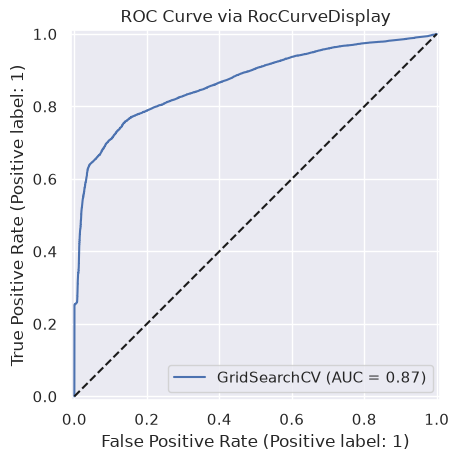

2026/07/14 00:08:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


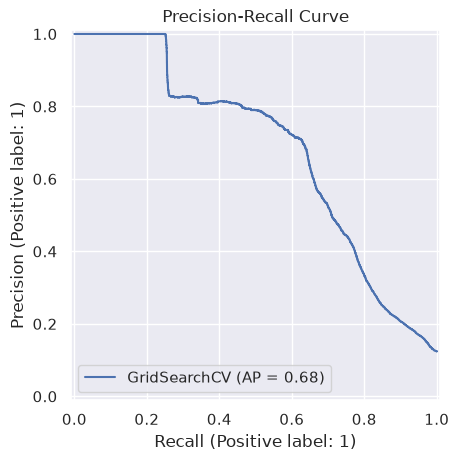

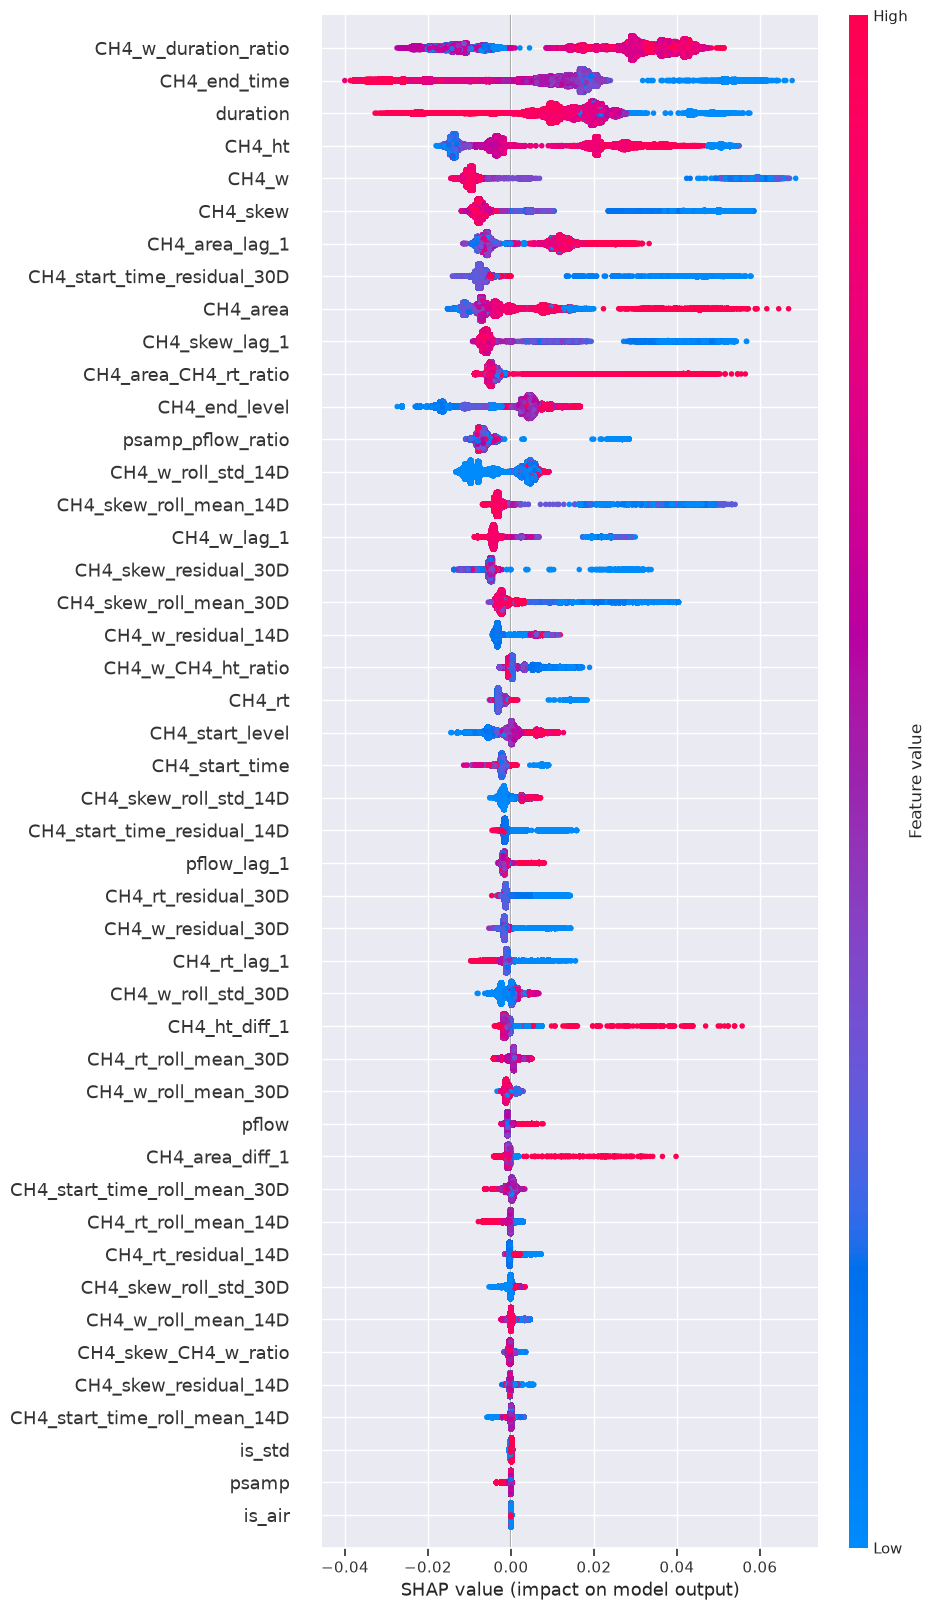

🏃 View run RF_GridSearch_120_rightone at: http://127.0.0.1:5000/#/experiments/4/runs/41adcb2dae854be09aca2b2129336dd9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
All Done!


In [44]:
with mlflow.start_run(run_name="RF_GridSearch_120_rightone") as parent_run:
    
    grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
    grid.fit(X_train_final, y_train_final)

    # print best model score
    cv_results = pd.DataFrame(grid.cv_results_)
    best_index = grid.best_index_
    mean_train = cv_results.loc[best_index, 'mean_train_score']
    mean_test = cv_results.loc[best_index, 'mean_test_score']

    print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
    print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

        
    X_test_final = tsfe.fit_transform(X_test)
    y_test_final = y_test.copy()
    #=========== plotting
    #======== ROC
    RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)
    
    plt.title("ROC Curve via RocCurveDisplay")
    plt.plot([0, 1], [0,1], 'k--') 
    plt.savefig("image/ROC_Curve.png")
    mlflow.log_artifact("image/ROC_Curve.png")
    plt.show()    
    plt.close()
    # ======= PRC 
    PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

    plt.title("Precision-Recall Curve")
    plt.savefig("image/PRC_Curve.png")
    mlflow.log_artifact("image/PRC_Curve.png")
    plt.show()    
    plt.close()
    #========= SHAP
    best_pipeline = grid.best_estimator_
    final_rf_model = best_pipeline.named_steps['clf']


    explainer = shap.TreeExplainer(final_rf_model)
    shap_values = explainer(X_test_final)

    plt.figure(figsize=(10,15))
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=46, show=False)
    plt.savefig("image/shap_summary.png")
    mlflow.log_artifact("image/shap_summary.png")
    plt.show()    
    plt.close()


print("All Done!")
    


    

    

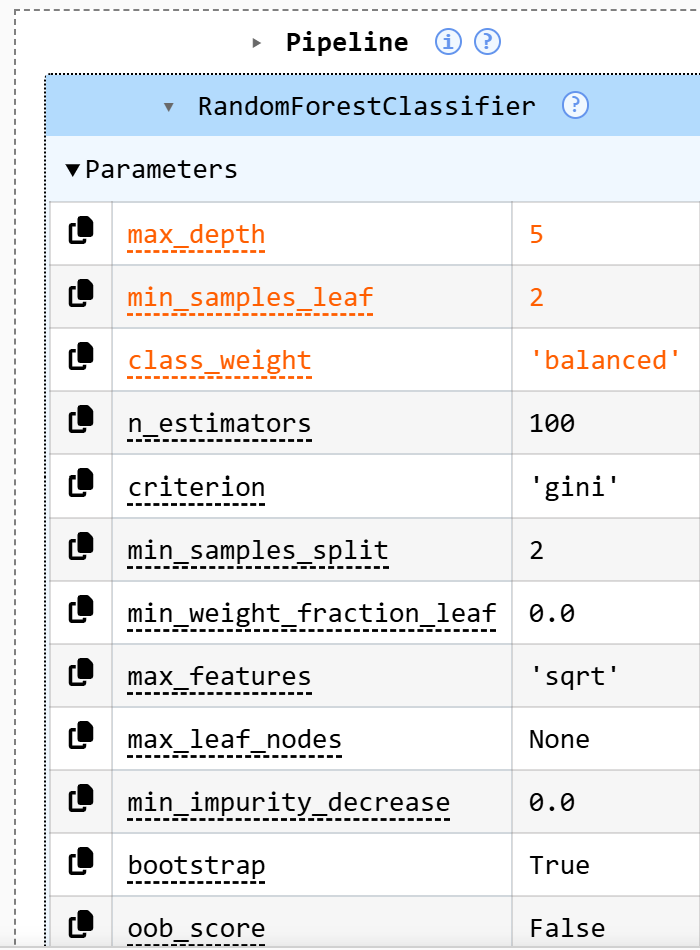

the best one above

cv_results = pd.DataFrame(grid.cv_results_)
best_index = grid.best_index_
mean_train = cv_results.loc[best_index, 'mean_train_score']
mean_test = cv_results.loc[best_index, 'mean_test_score']

print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

In [42]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](46,)","['psamp','pflow','CH4_rt',...,'CH4_skew_residual_14D', 'CH4_skew_roll_mean_30D','CH4_skew_residual_30D']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,46
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",120
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [ ]:
joblib.dump(grid.best_estimator_, 'model/07_rf_best_grid_v2.pkl')

['model/0706_rf_best_grid_v2.pkl']

In [24]:
joblib.dump(grid, 'model/0706_rf_grid_v2.pkl')
print('Done!')

Done!


grid = joblib.load('model/0706_rf_grid_v1.pkl')

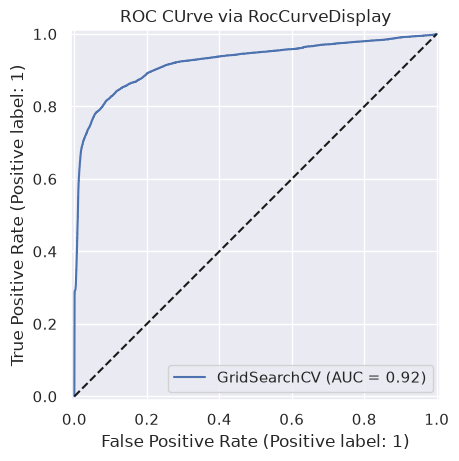

In [26]:
X_test_final = tsfe.fit_transform(X_test)
y_test_final = y_test.copy()
RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--') 
plt.show()


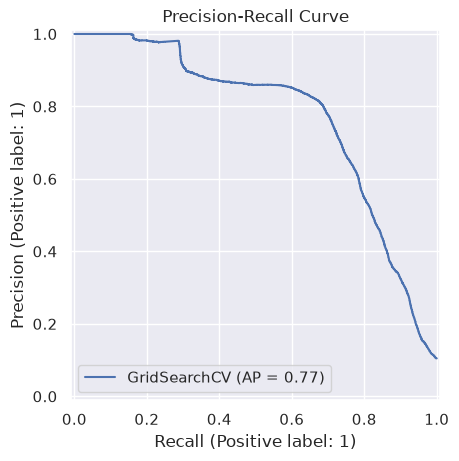

In [ ]:

PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('Precision-Recall Curve')
plt.show()

In [29]:
X_test_final.columns

Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'is_ht_zero_and_C_Nan', 'is_normal_std',
       'CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio',
       'w_duration_ratio', 'CH4_area_diff_1', 'CH4_ht_diff_1',
       'CH4_area_lag_1', 'CH4_rt_lag_1', 'pflow_lag_1', 'CH4_w_lag_1',
       'CH4_skew_lag_1', 'CH4_w_roll_std_14D', 'CH4_skew_roll_std_14D',
       'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D'],
      dtype='object')

In [ ]:
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']

X_tsfe_demo = best_pipeline.named_steps['tsfe'].transform(X_test.head(2))
X_tsfe_demo.head()

,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,is_ht_zero_and_C_Nan,is_bad_std,is_normal_std,is_protential_flagged_air,CH4_area_ht_ratio,CH4_w_ht_ratio,psamp_pflow_ratio,w_duration_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_rt_diff_1,CH4_area_lag_1,CH4_rt_lag_1,tmod_lag_1,tamb_lag_1,pflow_lag_1,psamp_lag_1,pamb_lag_1,CH4_w_lag_1,CH4_skew_lag_1,CH4_w_roll_std_14D,CH4_skew_roll_std_14D,CH4_rt_roll_mean_14D,CH4_rt_residual_14D,CH4_start_time_roll_mean_14D,CH4_start_time_residual_14D,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_skew_roll_mean_14D,CH4_skew_residual_14D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-07-21 18:43:00,40.0,19.77,803.7,752.75,752.7,102.2,7.37,142932.0,1230362.0,0.9,88.2,140.8,29213.0,29627.0,52.6,0,0,1,0,8.608023,0.000052,0.936606,0.140114,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,102.2,0.0,88.2,0.00,7.37,0.0,0.9
2019-07-21 19:03:00,40.0,19.73,806.8,752.89,752.8,102.2,7.39,139718.0,1206045.0,0.9,88.2,140.6,29194.0,29662.0,52.4,0,0,0,0,8.631994,0.000053,0.933180,0.141031,-24317.0,-3214.0,0.0,1230362.0,102.2,40.0,19.77,803.7,752.75,752.7,7.37,0.9,0.0,0.0,102.2,0.0,88.2,0.0,7.37,0.02,0.9,0.0


In [ ]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)


feature_names = X_test_final.columns

X_test_transformed_df = pd.DataFrame(X_test_final, columns =feature_names)
X_test_transformed_df.isna().sum()

tmod                            0
tamb                            0
pflow                           0
psamp                           0
pamb                            0
CH4_rt                          0
CH4_w                           0
CH4_ht                          0
CH4_area                        0
CH4_skew                        0
CH4_start_time                  0
CH4_end_time                    0
CH4_start_level                 0
CH4_end_level                   0
duration                        0
is_ht_zero_and_C_Nan            0
is_bad_std                      0
is_normal_std                   0
is_protential_flagged_air       0
CH4_area_ht_ratio               0
CH4_w_ht_ratio                  0
psamp_pflow_ratio               0
w_duration_ratio                0
CH4_area_diff_1                 0
CH4_ht_diff_1                   0
CH4_rt_diff_1                   0
CH4_area_lag_1                  0
CH4_rt_lag_1                    0
tmod_lag_1                      0
tamb_lag_1    

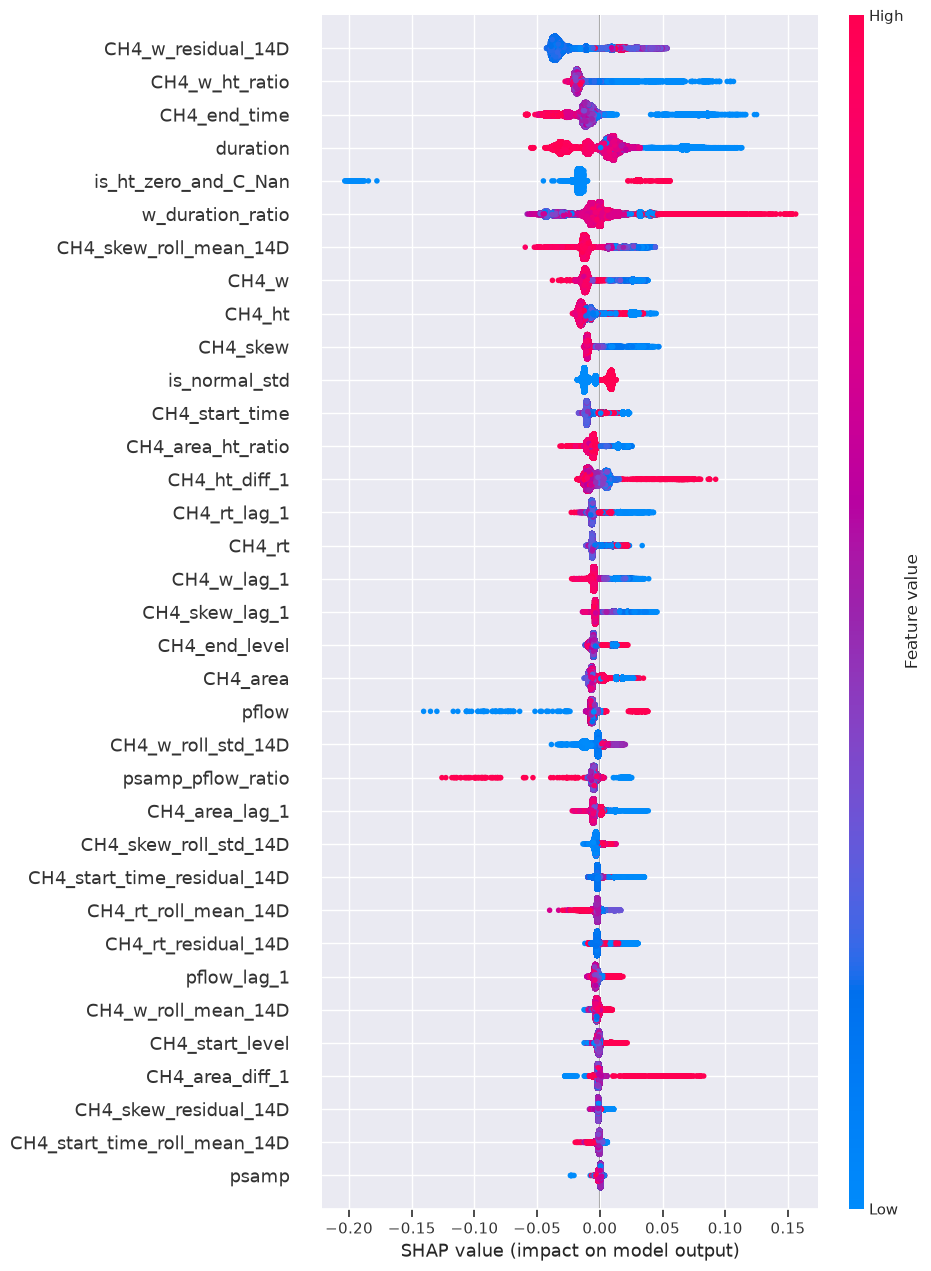

In [30]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)

explainer = shap.TreeExplainer(final_rf_model)
shap_values = explainer(X_test_final)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=46) # label1 = 1

------

In [ ]:
# Learning curve
from sklearn.model_selection import LearningCurveDisplay
best_param = grid.best_estimator_

eval_pipeline = pipe_rnd.set_params(**best_param)

LearningCurveDisplay.from_estimator(
    eval_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    n_jobs=-1
)

plt.title("Learning Curve (Random Forest)")
plt.show()